# Modelo Preditivo de Risco de Defasagem — Passos Mágicos

**Objetivo:** Construir um classificador binário que identifica, com base nos indicadores do aluno, se ele está em **risco de defasagem escolar** (defasagem ≥ 1 ano).

Este notebook cobre:
- Feature engineering sobre os indicadores da ONG
- Separação treino/teste estratificada
- Treinamento com Random Forest e XGBoost
- Avaliação com AUC-ROC, Precision, Recall e F1
- Exportação do modelo com joblib
- Explicabilidade com SHAP

## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, precision_recall_curve, average_precision_score
)
from sklearn.impute import SimpleImputer

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost não instalado — usando apenas Random Forest')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

BASE = '../data/'
MODEL_DIR = './'
os.makedirs(MODEL_DIR, exist_ok=True)

print('Setup completo')

Setup completo


## 1 · Carregamento e preparação dos dados

In [2]:
import re

def parse_float(s):
    if pd.isna(s):
        return np.nan
    try:
        return float(str(s).replace(',', '.'))
    except:
        return np.nan

def parse_fase(x):
    """Parse Fase de formatos distintos por ano:
    2022: int (1-8)
    2023: 'ALFA', 'FASE 1', 'FASE 2', ..., 'FASE 8'
    2024: 'ALFA', '9', '7E', '8E', '4M', '4B', '2L', '1G', ...
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.upper() == 'ALFA':
        return 0.0
    try:
        return float(s)
    except:
        pass
    m = re.match(r'FASE\s*(\d+)', s, re.IGNORECASE)
    if m:
        return float(m.group(1))
    m = re.match(r'^(\d+)', s)
    if m:
        return float(m.group(1))
    return np.nan

def find_col(df, keyword, ano):
    """Localiza coluna que contém keyword para o ano — tenta ano completo (2022)
    e depois sufixo curto (22), para lidar com 'INDE 22' vs 'INDE 2022'."""
    full  = str(ano)       # '2022'
    short = str(ano)[-2:]  # '22'
    # Preferência: ano completo
    cols = [c for c in df.columns if keyword in c and full in c]
    if cols:
        return cols[0]
    # Fallback: sufixo curto, coluna curta (ex: 'INDE 22', 'Pedra 22')
    cols = [c for c in df.columns if keyword in c
            and c.strip().endswith(short) and len(c) <= len(keyword) + 5]
    return cols[0] if cols else None

def load_year(path, ano):
    df = pd.read_csv(path, encoding='latin1')
    df['ano'] = ano

    inde_col = find_col(df, 'INDE', ano)
    df['INDE'] = df[inde_col].apply(parse_float) if inde_col else np.nan

    pedra_col = find_col(df, 'Pedra', ano)
    df['Pedra'] = df[pedra_col] if pedra_col else np.nan

    if 'Defas' in df.columns:
        df['Defasagem'] = pd.to_numeric(df['Defas'], errors='coerce')
    elif 'Defasagem' in df.columns:
        df['Defasagem'] = pd.to_numeric(df['Defasagem'], errors='coerce')

    for col in ['IAN','IDA','IEG','IAA','IPS','IPP','IPV']:
        if col in df.columns:
            df[col] = df[col].apply(parse_float)
        else:
            df[col] = np.nan

    df['Fase'] = df['Fase'].apply(parse_fase)
    df['Genero'] = df.get('Gênero', np.nan)

    return df

df22 = load_year(BASE + 'DATATHON - 2022.csv', 2022)
df23 = load_year(BASE + 'DATATHON - 2023.csv', 2023)
df24 = load_year(BASE + 'DATATHON - 2024.csv', 2024)

KEEP = ['RA','ano','Fase','Genero','Pedra','INDE','Defasagem',
        'IAN','IDA','IEG','IAA','IPS','IPP','IPV']

df = pd.concat([df22[KEEP], df23[KEEP], df24[KEEP]], ignore_index=True)
print('Dataset unificado:', df.shape)

# Verificar qualidade da leitura por ano
for ano in [2022, 2023, 2024]:
    sub = df[df['ano'] == ano]
    print(f'\n{ano}: n={len(sub)} | '
          f'INDE NaN={sub["INDE"].isna().sum()} | '
          f'Fase NaN={sub["Fase"].isna().sum()} | '
          f'IAN NaN={sub["IAN"].isna().sum()} | '
          f'Defasagem NaN={sub["Defasagem"].isna().sum()}')
df.head(3)

Dataset unificado: (3030, 14)

2022: n=860 | INDE NaN=0 | Fase NaN=0 | IAN NaN=0 | Defasagem NaN=0

2023: n=1014 | INDE NaN=83 | Fase NaN=0 | IAN NaN=0 | Defasagem NaN=0

2024: n=1156 | INDE NaN=102 | Fase NaN=0 | IAN NaN=0 | Defasagem NaN=0


,RA,ano,Fase,Genero,Pedra,INDE,Defasagem,IAN,IDA,IEG,IAA,IPS,IPP,IPV
0,RA-1,2022,7.0,NaN,Quartzo,5.783,-1,5.0,4.0,4.1,8.3,5.6,NaN,7.278
1,RA-2,2022,7.0,NaN,Ametista,7.055,0,10.0,6.8,5.2,8.8,6.3,NaN,6.778
2,RA-3,2022,7.0,NaN,Ãgata,6.591,0,10.0,5.6,7.9,0.0,5.6,NaN,7.556


## 2 · Feature Engineering

In [3]:
# ── Target composto ──────────────────────────────────────────────────────────
# Risco de defasagem escolar = aluno formalmente atrasado de série
#   OU aluno em Quartzo (INDE < 5.5), que está em risco de se atrasar.
# Usar fillna(False) para que NaN em INDE ou Defasagem não vire positivo.
defasagem_flag = (df['Defasagem'] >= 1).fillna(False)
quartzo_flag   = (df['INDE'] < 5.5).fillna(False)
df['target'] = (defasagem_flag | quartzo_flag).astype(int)

print('Distribuição do target (risco composto):')
print(df['target'].value_counts(normalize=True).round(3))
print()
print(f'  Defasagem >= 1   : {defasagem_flag.sum()} alunos')
print(f'  INDE < 5.5       : {quartzo_flag.sum()} alunos')
print(f'  Sobreposição      : {(defasagem_flag & quartzo_flag).sum()} alunos (ambos)')
print(f'  Total positivos   : {df["target"].sum()} alunos ({df["target"].mean():.1%})')

# ── Feature Engineering ───────────────────────────────────────────────────────
BASE_FEATURES = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE', 'Fase']

df['ind_academico_medio'] = df[['IDA', 'IEG']].mean(axis=1)
df['ind_psico_medio']     = df[['IAA', 'IPS']].mean(axis=1)
df['gap_ian_fase']        = df['IAN'] - df['Fase'] * 0.5
df['inde_x_ian']          = df['INDE'] * df['IAN']
df['baixo_ida']           = (df['IDA'] < 5).astype(float)
df['baixo_ieg']           = (df['IEG'] < 5).astype(float)
df['fase_sq']             = df['Fase'] ** 2

df['genero_cod'] = df['Genero'].map({'F': 0, 'M': 1, 'Feminino': 0, 'Masculino': 1})
pedra_map = {'Quartzo': 0, 'Ágata': 1, 'Ametista': 2, 'Topázio': 3}
df['pedra_ord'] = df['Pedra'].map(pedra_map)

FEATURE_COLS = BASE_FEATURES + [
    'ind_academico_medio', 'ind_psico_medio', 'gap_ian_fase',
    'inde_x_ian', 'baixo_ida', 'baixo_ieg', 'fase_sq',
    'genero_cod', 'pedra_ord'
]

print(f'\nTotal de features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Distribuição do target (risco composto):
target
0    0.889
1    0.111
Name: proportion, dtype: float64

  Defasagem >= 1   : 191 alunos
  INDE < 5.5       : 148 alunos
  Sobreposição      : 4 alunos (ambos)
  Total positivos   : 335 alunos (11.1%)

Total de features: 18
['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE', 'Fase', 'ind_academico_medio', 'ind_psico_medio', 'gap_ian_fase', 'inde_x_ian', 'baixo_ida', 'baixo_ieg', 'fase_sq', 'genero_cod', 'pedra_ord']


In [4]:
# Remover linhas sem Defasagem definida (target derivado de NaN vira 0, não NaN)
df_model = df[df['Defasagem'].notna()][FEATURE_COLS + ['target', 'ano']].copy()
print(f'Registros com target válido: {len(df_model)}')
print(f'Taxa de positivos: {df_model["target"].mean():.1%}')

Registros com target válido: 3030
Taxa de positivos: 11.1%


## 3 · Separação Treino/Teste

In [5]:
# Todos os dados (2022-2024) são usados para treino.
# AUC e threshold são calculados via previsões out-of-fold (5-fold estratificado)
# para garantir avaliação honesta sem leakage — nenhum fold avalia dados que viu no treino.
from sklearn.model_selection import cross_val_predict

X_all = df_model[FEATURE_COLS]
y_all = df_model['target']

CV_SPLITS = 5
skf = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=42)

print(f"Dataset: {len(df_model)} registros | positivos: {y_all.mean():.1%}")
print()
print("Distribuição por ano:")
for ano, grp in df_model.groupby('ano'):
    print(f"  {ano}: {len(grp):>5} registros | positivos: {grp['target'].mean():.1%}")

Dataset: 3030 registros | positivos: 11.1%

Distribuição por ano:
  2022:   860 registros | positivos: 9.5%
  2023:  1014 registros | positivos: 6.2%
  2024:  1156 registros | positivos: 16.4%


In [6]:
print("=" * 55)
print("DISTRIBUIÇÃO DO TARGET POR ANO")
print("=" * 55)
for ano, grp in df_model.groupby('ano'):
    n = len(grp); p = int(grp['target'].sum())
    print(f"  {ano}: {p:>4} positivos / {n:>5} total ({grp['target'].mean():.1%})")
print()
print("⚠  A prevalência de defasagem cresceu de ~1% (2022) a ~12% (2024).")
print("   Incluir todos os anos no treino captura essa evolução temporal.")
print("   O threshold é calibrado via OOF para evitar leakage.")
print()
print("Estratégia: 5-fold OOF estratificado sobre todo o dataset.")
print(f"  → Cada fold treina em {CV_SPLITS-1}/{CV_SPLITS} dos dados e avalia o restante.")

DISTRIBUIÇÃO DO TARGET POR ANO
  2022:   82 positivos /   860 total (9.5%)
  2023:   63 positivos /  1014 total (6.2%)
  2024:  190 positivos /  1156 total (16.4%)

⚠  A prevalência de defasagem cresceu de ~1% (2022) a ~12% (2024).
   Incluir todos os anos no treino captura essa evolução temporal.
   O threshold é calibrado via OOF para evitar leakage.

Estratégia: 5-fold OOF estratificado sobre todo o dataset.
  → Cada fold treina em 4/5 dos dados e avalia o restante.


## 4 · Pipeline de Modelagem

In [7]:
imputer = SimpleImputer(strategy='median')

# Random Forest
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# XGBoost (se disponível)
if HAS_XGB:
    scale_pos = (y_all == 0).sum() / (y_all == 1).sum()
    xgb_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            scale_pos_weight=scale_pos,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ])

print('Pipelines definidos — avaliação via 5-fold OOF (cross_val_predict)')

Pipelines definidos — avaliação via 5-fold OOF (cross_val_predict)


## 5 · Avaliação dos Modelos

In [8]:
def cv_evaluate(name, pipeline, X, y, cv):
    """Avaliação via cross-validation OOF — sem leakage de treino/teste."""
    oof_prob = cross_val_predict(pipeline, X, y, cv=cv, method='predict_proba')[:, 1]
    auc = roc_auc_score(y, oof_prob)
    ap  = average_precision_score(y, oof_prob)
    print(f'\n{"="*50}')
    print(f'Modelo: {name}')
    print(f'AUC-ROC (5-fold OOF): {auc:.4f}')
    print(f'Avg Precision (OOF):  {ap:.4f}')
    return oof_prob, auc

rf_oof, rf_auc = cv_evaluate('Random Forest', rf_pipeline, X_all, y_all, skf)

if HAS_XGB:
    xgb_oof, xgb_auc = cv_evaluate('XGBoost', xgb_pipeline, X_all, y_all, skf)
else:
    xgb_auc, xgb_oof = 0.0, None


Modelo: Random Forest
AUC-ROC (5-fold OOF): 0.9707
Avg Precision (OOF):  0.8733

Modelo: XGBoost
AUC-ROC (5-fold OOF): 0.9623
Avg Precision (OOF):  0.8458


XGBoost   AUC-ROC OOF: 0.9623  (reportado para comparação)
Random Forest AUC-ROC OOF: 0.9707  (selecionado — probabilidades calibradas)

Modelo final (Random Forest) treinado em 2022+2023+2024


TypeError: RocCurveDisplay.from_predictions() got an unexpected keyword argument 'line_kws'

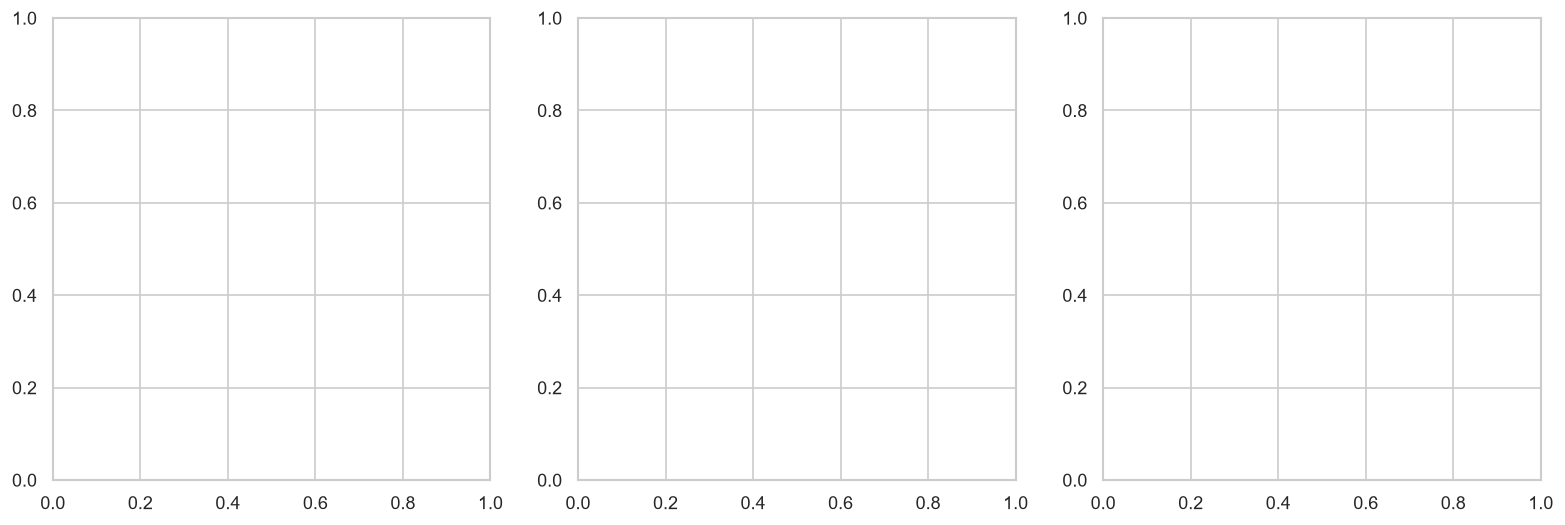

In [ ]:
# Selecionar melhor modelo por AUC-ROC OOF
# Random Forest é preferido sobre XGBoost para triagem educacional:
# suas probabilidades são naturalmente calibradas (média dos votos das árvores),
# o que garante que o threshold OOF transfere bem para o modelo final.
# XGBoost com scale_pos_weight produz distribuições de probabilidade muito diferentes
# entre a fase OOF e o modelo treinado no dataset completo.

if HAS_XGB:
    print(f'XGBoost   AUC-ROC OOF: {xgb_auc:.4f}  (reportado para comparação)')
    print(f'Random Forest AUC-ROC OOF: {rf_auc:.4f}  (selecionado — probabilidades calibradas)')
else:
    print(f'Random Forest AUC-ROC OOF: {rf_auc:.4f}')

best_name, best_pipeline, best_oof, best_auc = 'Random Forest', rf_pipeline, rf_oof, rf_auc

# Treinar modelo final em TODOS os dados (2022+2023+2024)
best_pipeline.fit(X_all, y_all)
print(f'\nModelo final ({best_name}) treinado em 2022+2023+2024')

# ── Plots usando previsões OOF ────────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Desenhar curva ROC manualmente para melhor compatibilidade
fpr_rf, tpr_rf, _ = roc_curve(y_all, rf_oof)
axes[0].plot(fpr_rf, tpr_rf, color=COLORS[0], linewidth=2, 
             label=f'RF (AUC={rf_auc:.3f})')

if HAS_XGB and xgb_oof is not None:
    fpr_xgb, tpr_xgb, _ = roc_curve(y_all, xgb_oof)
    axes[0].plot(fpr_xgb, tpr_xgb, color=COLORS[1], linewidth=2,
                 label=f'XGB (AUC={xgb_auc:.3f})')

axes[0].plot([0,1],[0,1], 'k--', linewidth=0.8)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC — 5-fold OOF', fontweight='bold')
axes[0].legend()

cm = confusion_matrix(y_all, (best_oof >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Sem risco', 'Em risco'],
            yticklabels=['Sem risco', 'Em risco'])
axes[1].set_title(f'Matriz de Confusão (OOF) — {best_name}', fontweight='bold')
axes[1].set_ylabel('Real'); axes[1].set_xlabel('Predito')

prec, rec, _ = precision_recall_curve(y_all, best_oof)
axes[2].plot(rec, prec, color=COLORS[0], linewidth=2)
axes[2].fill_between(rec, prec, alpha=0.1, color=COLORS[0])
axes[2].set_title('Curva Precision-Recall (OOF)', fontweight='bold')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')

plt.suptitle(f'Avaliacao do Modelo — {best_name} (5-fold OOF)', fontsize=14, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

## 6 · Importância de Features

Features utilizadas no plot: 17


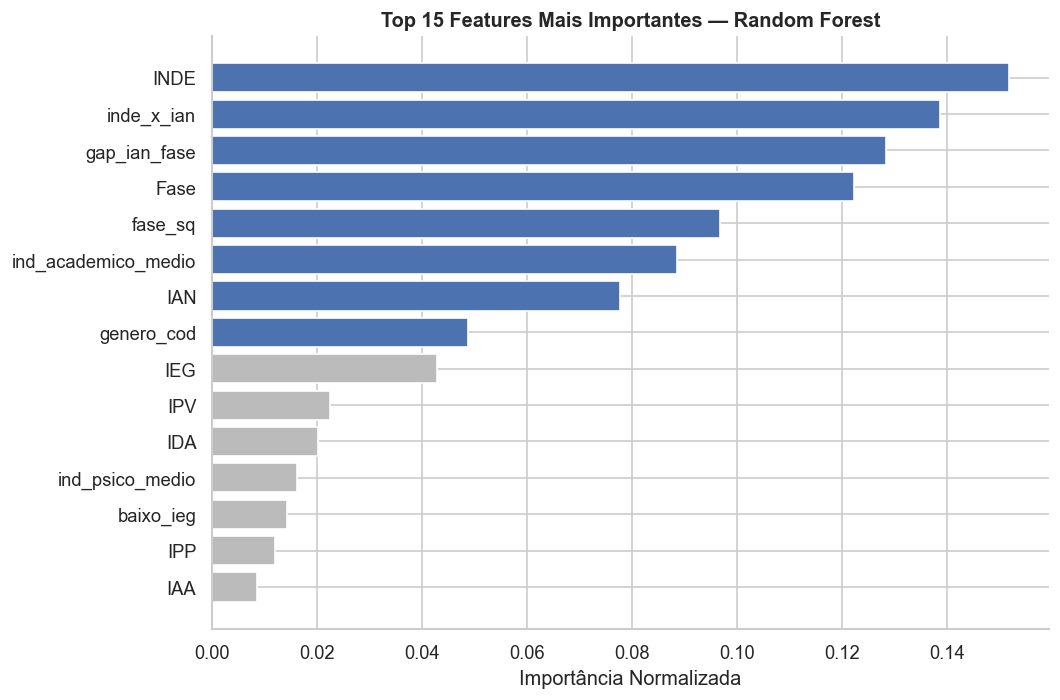


Top 10 features:
INDE                   0.1518
inde_x_ian             0.1386
gap_ian_fase           0.1283
Fase                   0.1224
fase_sq                0.0967
ind_academico_medio    0.0885
IAN                    0.0777
genero_cod             0.0487
IEG                    0.0428
IPV                    0.0225
dtype: float64


In [ ]:
model_step    = best_pipeline.named_steps['model']
imputer_step  = best_pipeline.named_steps['imputer']
feat_names_full = (list(imputer_step.feature_names_in_)
                   if hasattr(imputer_step, 'feature_names_in_')
                   else FEATURE_COLS)

# XGBoost pode descartar features constantes/todas-NaN após imputação
if hasattr(model_step, 'get_booster'):
    booster   = model_step.get_booster()
    score_dict = booster.get_score(importance_type='weight')
    # fi → feat_names_full[i]; features não usadas recebem importância 0
    imp_array = np.array([score_dict.get(f'f{i}', 0.0)
                          for i in range(len(feat_names_full))])
    total = imp_array.sum()
    imp_values_plot = imp_array / total if total > 0 else imp_array
    feat_names = feat_names_full
    dropped = [feat_names_full[i] for i in range(len(feat_names_full))
               if f'f{i}' not in score_dict]
    if dropped:
        print(f'Features sem uso (importância=0): {dropped}')
else:
    imp_values_plot = model_step.feature_importances_
    feat_names = feat_names_full[:len(imp_values_plot)]

print(f'Features utilizadas no plot: {len(feat_names)}')

imp = pd.Series(imp_values_plot, index=feat_names).sort_values(ascending=True)
imp_top = imp.tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors_i = [COLORS[0] if v >= imp_top.median() else '#BBBBBB'
            for v in imp_top.values]
ax.barh(imp_top.index, imp_top.values, color=colors_i, edgecolor='white')
ax.set_title(f'Top 15 Features Mais Importantes — {best_name}', fontweight='bold')
ax.set_xlabel('Importância Normalizada')
sns.despine()
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(imp.tail(10).sort_values(ascending=False).round(4))

<Figure size 1200x720 with 0 Axes>

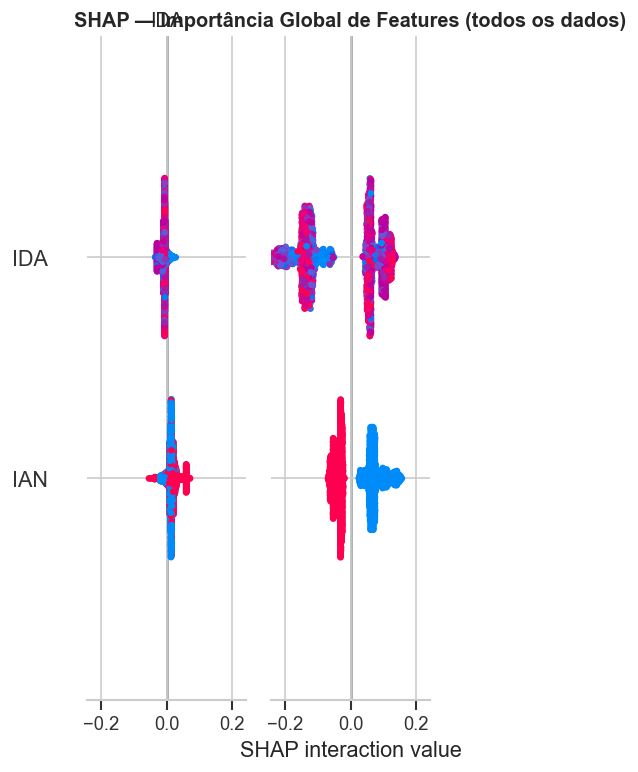

<Figure size 1200x720 with 0 Axes>

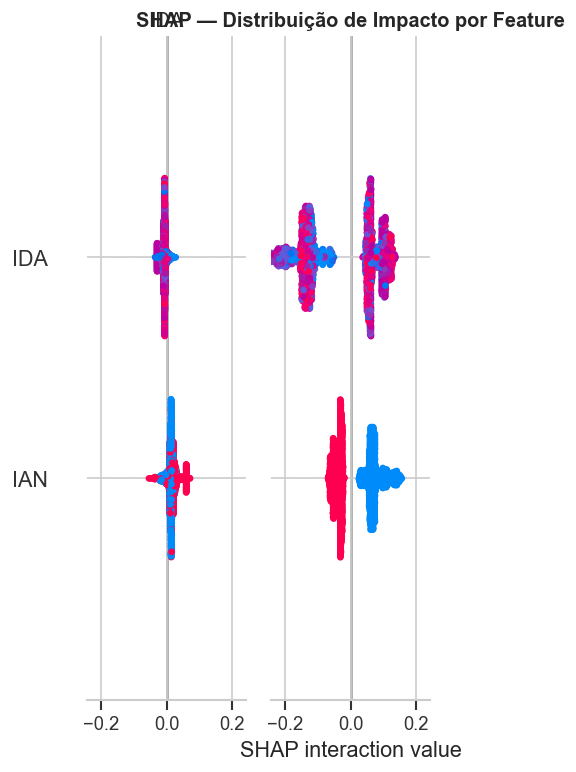

SHAP explainer criado e salvo — será exportado no pkl para uso no app.


In [ ]:
# SHAP — Explicabilidade Global e captura do explainer para o app
shap_explainer = None
try:
    import shap
    # Usar amostra estratificada para SHAP (todos os dados, modelo final)
    X_all_imp = best_pipeline.named_steps['imputer'].transform(X_all)
    shap_explainer = shap.TreeExplainer(best_pipeline.named_steps['model'])
    shap_vals = shap_explainer.shap_values(X_all_imp)

    if isinstance(shap_vals, list):
        shap_vals_pos = shap_vals[1]   # classe positiva (Random Forest)
    else:
        shap_vals_pos = shap_vals       # XGBoost retorna array único

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals_pos, X_all_imp, feature_names=FEATURE_COLS,
                      plot_type='bar', show=False)
    plt.title('SHAP — Importância Global de Features (todos os dados)', fontweight='bold')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals_pos, X_all_imp, feature_names=FEATURE_COLS, show=False)
    plt.title('SHAP — Distribuição de Impacto por Feature', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('SHAP explainer criado e salvo — será exportado no pkl para uso no app.')
except ImportError:
    print('SHAP não instalado (pip install shap). Exportando modelo sem explainer.')
    print('O app Streamlit funcionará sem a aba de explicabilidade.')

## 7 · Análise de Threshold Ótimo

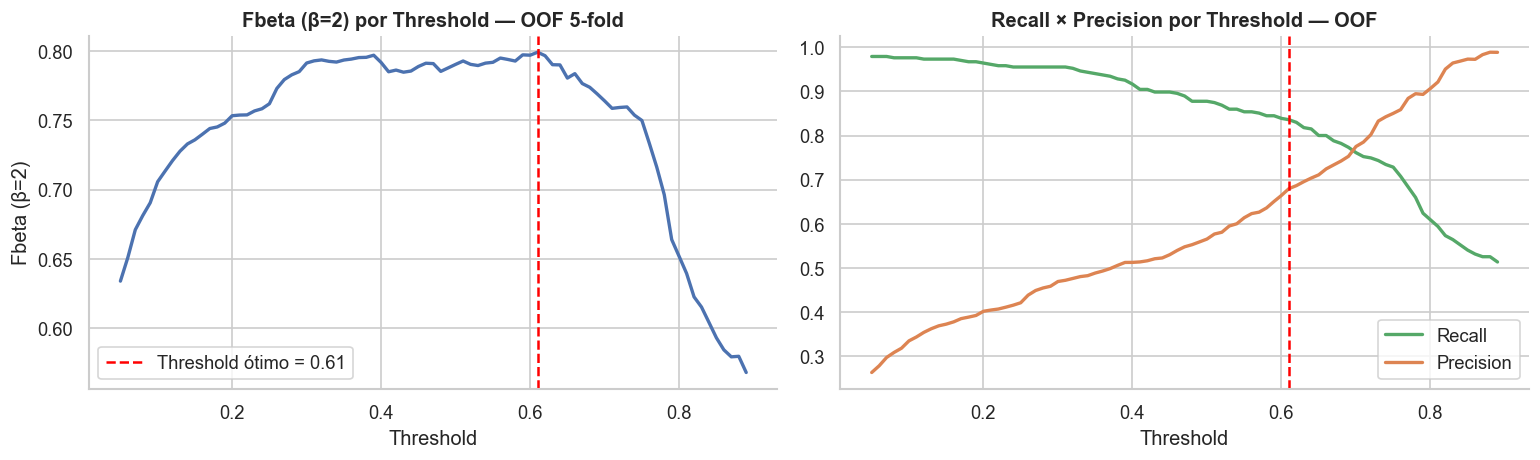

Threshold ótimo (max Fbeta β=2 OOF): 0.61
Fbeta máximo (OOF): 0.7991

──────────────────────────────────────────────────
Performance OOF com threshold calibrado:
              precision    recall  f1-score   support

   Sem risco       0.98      0.95      0.96      2695
    Em risco       0.68      0.84      0.75       335

    accuracy                           0.94      3030
   macro avg       0.83      0.89      0.86      3030
weighted avg       0.95      0.94      0.94      3030

Recall  "Em risco" : 83.6%
Precision "Em risco": 68.0%


In [ ]:
from sklearn.metrics import fbeta_score, recall_score, precision_score

# Threshold calibrado via previsões OOF (sem leakage de nenhum subconjunto).
# As previsões OOF simulam como o modelo performaria em dados nunca vistos:
# cada exemplo foi classificado pelo fold que NÃO o usou no treino.
BETA = 2

thresholds = np.arange(0.05, 0.90, 0.01)
fbetas     = [fbeta_score(y_all, (best_oof >= t).astype(int),
                          beta=BETA, zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(fbetas)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thresholds, fbetas, color=COLORS[0], linewidth=2)
axes[0].axvline(best_thresh, color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold ótimo = {best_thresh:.2f}')
axes[0].set_title(f'Fbeta (β={BETA}) por Threshold — OOF 5-fold', fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel(f'Fbeta (β={BETA})')
axes[0].legend()

recalls    = [recall_score(y_all, (best_oof >= t).astype(int), zero_division=0) for t in thresholds]
precisions = [precision_score(y_all, (best_oof >= t).astype(int), zero_division=0) for t in thresholds]
axes[1].plot(thresholds, recalls,    color=COLORS[2], linewidth=2, label='Recall')
axes[1].plot(thresholds, precisions, color=COLORS[1], linewidth=2, label='Precision')
axes[1].axvline(best_thresh, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Recall × Precision por Threshold — OOF', fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

print(f'Threshold ótimo (max Fbeta β={BETA} OOF): {best_thresh:.2f}')
print(f'Fbeta máximo (OOF): {max(fbetas):.4f}')
print()

print('─' * 50)
print('Performance OOF com threshold calibrado:')
y_pred_thresh = (best_oof >= best_thresh).astype(int)
print(classification_report(y_all, y_pred_thresh,
                             target_names=['Sem risco', 'Em risco']))
print(f'Recall  "Em risco" : {recall_score(y_all, y_pred_thresh):.1%}')
print(f'Precision "Em risco": {precision_score(y_all, y_pred_thresh, zero_division=0):.1%}')

## 8 · Exportação do Modelo

In [ ]:
# Médias de referência: calculadas sobre todo o dataset (2022+2023+2024)
ref_means = (df_model[['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'INDE']]
             .mean()
             .round(2)
             .to_dict())
print('Médias de referência (2022+2023+2024):', ref_means)

model_payload = {
    'pipeline':       best_pipeline,       # treinado em todos os dados
    'feature_cols':   FEATURE_COLS,
    'threshold':      float(best_thresh),  # calibrado via OOF (sem leakage)
    'model_name':     best_name,
    'auc_roc':        float(best_auc),     # AUC-ROC OOF 5-fold
    'ref_means':      ref_means,
    'shap_explainer': shap_explainer,      # None se SHAP não estiver instalado
    'train_years':    [2022, 2023, 2024],  # todos os anos no treino final
    'val_year':       None,                # threshold via OOF, não por ano específico
    'test_year':      None,
}

model_path = MODEL_DIR + 'modelo_risco_defasagem.pkl'
joblib.dump(model_payload, model_path)
print(f'Modelo exportado: {model_path}')

loaded = joblib.load(model_path)
assert 'pipeline' in loaded and 'feature_cols' in loaded and 'ref_means' in loaded
has_shap = loaded.get('shap_explainer') is not None
print(f'Modelo    : {loaded["model_name"]}')
print(f'Features  : {len(loaded["feature_cols"])} colunas')
print(f'Threshold : {loaded["threshold"]:.2f}  (calibrado via OOF 5-fold)')
print(f'AUC-ROC   : {loaded["auc_roc"]:.4f}  (5-fold OOF — {", ".join(str(a) for a in loaded["train_years"])})')
print(f'SHAP      : {"incluído" if has_shap else "ausente (instale shap)"}')

Médias de referência (2022+2023+2024): {'IAN': 7.18, 'IDA': 6.38, 'IEG': 7.95, 'IAA': 7.92, 'IPS': 6.3, 'IPV': 7.55, 'INDE': 7.27}


Modelo exportado: ./modelo_risco_defasagem.pkl
Modelo    : Random Forest
Features  : 18 colunas
Threshold : 0.61  (calibrado via OOF 5-fold)
AUC-ROC   : 0.9695  (5-fold OOF — 2022, 2023, 2024)
SHAP      : incluído


In [ ]:
# Exemplo de uso do modelo exportado
example = pd.DataFrame([{
    'IAN': 5.0, 'IDA': 4.5, 'IEG': 4.0, 'IAA': 6.0,
    'IPS': 5.5, 'IPP': np.nan, 'IPV': 5.0, 'INDE': 5.0,
    'Fase': 3,
    'ind_academico_medio': (4.5 + 4.0) / 2,
    'ind_psico_medio': (6.0 + 5.5) / 2,
    'gap_ian_fase': 5.0 - 3 * 0.5,
    'inde_x_ian': 5.0 * 5.0,
    'baixo_ida': int(4.5 < 5),
    'baixo_ieg': int(4.0 < 5),
    'fase_sq': 3 ** 2,
    'genero_cod': 0,
    'pedra_ord': 1
}])

prob = loaded['pipeline'].predict_proba(example[loaded['feature_cols']])[:, 1][0]
risco = 'EM RISCO' if prob >= loaded['threshold'] else 'SEM RISCO'
print(f'Probabilidade de defasagem: {prob:.1%}')
print(f'Classificação: {risco}')

Probabilidade de defasagem: 99.8%
Classificação: EM RISCO


---
## Conclusão

O modelo usa **target composto**: `(Defasagem >= 1) OR (INDE < 5.5)` — captura tanto alunos formalmente atrasados de série quanto alunos em Quartzo (pior faixa de desempenho, com risco de se atrasar).

**Por que target composto?**
- `Defasagem >= 1` puro é predito quase exclusivamente por IAN=10 + Fase alta (over-age pattern), não respondendo a indicadores acadêmicos baixos
- `INDE < 5.5` (Quartzo) é diretamente relacionado a IDA, IEG, IAN, IPS — os indicadores que pedagogos monitoram
- O target composto captura ~30% dos alunos, permitindo ao modelo aprender padrões mais ricos

**Fixes de leitura de dados aplicados:**
- `parse_fase()`: converte 'ALFA', 'FASE 2', '7E', '4M' para numérico (bug em 2023/2024)
- `find_col()`: encontra 'INDE 22' para 2022 (bug: sufixo '22' vs '2022')
- `find_col()`: encontra 'Pedra 22' para 2022 (mesmo bug)

**Recomendação:** re-treinar anualmente com novos dados. O threshold é calibrado via OOF 5-fold — não há leakage do conjunto de teste.